# S&P 500 과거 데이터 분석 (2000년 ~ 2019년)

이 노트북은 `S&P 500 과거 데이터.csv` 파일을 pandas로 정제하고, 2000년 초부터 2019년 말까지의 구간을 다각도로 분석한 뒤 종가 기준 라인 그래프를 시각화합니다.

## 1. 라이브러리 임포트 및 한글/시각화 기본 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# 한글 폰트 설정 (Windows 기준 맑은 고딕, 없으면 기본 폰트 사용)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 시각화 기본 옵션
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
mpl.rcParams['grid.alpha'] = 0.3

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print("라이브러리 임포트 및 기본 설정 완료")

라이브러리 임포트 및 기본 설정 완료


## 2. CSV 로드 및 원본 스키마 점검

CSV 파일을 로드하고 `head()`, `info()`, `columns`, `dtypes`로 원본 데이터의 구조와 상태를 확인합니다.

In [2]:
FILE_PATH = r"c:\work\S&P 500 과거 데이터.csv"

raw_df = pd.read_csv(FILE_PATH)

print("=== head() ===")
display(raw_df.head())

print("\n=== info() ===")
raw_df.info()

print("\n=== columns ===")
print(raw_df.columns.tolist())

print("\n=== dtypes ===")
print(raw_df.dtypes)

=== head() ===


,날짜,종가,시가,고가,저가,거래량,변동 %
0,2019- 11- 14,"3,096.60","3,090.80","3,098.20","3,083.30",NaN,0.08%
1,2019- 11- 13,"3,094.00","3,084.20","3,098.10","3,078.80",NaN,0.07%
2,2019- 11- 12,"3,091.80","3,089.30","3,102.60","3,084.70",NaN,0.16%
3,2019- 11- 11,"3,087.00","3,080.30","3,088.30","3,075.80",NaN,-0.20%
4,2019- 11- 08,"3,093.10","3,081.20","3,093.10","3,073.60",NaN,0.26%



=== info() ===
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      5000 non-null   str    
 1   종가      5000 non-null   str    
 2   시가      5000 non-null   str    
 3   고가      5000 non-null   str    
 4   저가      5000 non-null   str    
 5   거래량     0 non-null      float64
 6   변동 %    5000 non-null   str    
dtypes: float64(1), str(6)
memory usage: 273.6 KB

=== columns ===
['날짜', '종가', '시가', '고가', '저가', '거래량', '변동 %']

=== dtypes ===
날짜          str
종가          str
시가          str
고가          str
저가          str
거래량     float64
변동 %        str
dtype: object


## 3. 문자형 수치 정리(쉼표/퍼센트/공백)와 타입 변환

`종가`, `시가`, `고가`, `저가`, `거래량`, `변동 %` 컬럼의 쉼표와 불필요한 공백, `%` 기호를 제거하고 `to_numeric`으로 숫자형으로 변환합니다. `변동 %`는 실수 비율(예: `0.08%` -> `0.0008`)로 변환합니다.

In [3]:
df = raw_df.copy()

price_cols = ['종가', '시가', '고가', '저가']

# 쉼표, 공백 제거 후 숫자형으로 변환
for col in price_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 거래량: 빈 문자열이 많으므로 결측으로 처리 후 숫자형 변환
df['거래량'] = (
    df['거래량']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace('', np.nan)
)
df['거래량'] = pd.to_numeric(df['거래량'], errors='coerce')

# 변동 %: % 기호 제거 후 실수 비율로 변환 (예: '0.08%' -> 0.0008)
df['변동 %'] = (
    df['변동 %']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.strip()
)
df['변동 %'] = pd.to_numeric(df['변동 %'], errors='coerce') / 100

print("=== 변환 후 dtypes ===")
print(df.dtypes)

display(df.head())

=== 변환 후 dtypes ===
날짜          str
종가      float64
시가      float64
고가      float64
저가      float64
거래량     float64
변동 %    float64
dtype: object


,날짜,종가,시가,고가,저가,거래량,변동 %
0,2019- 11- 14,3096.6,3090.8,3098.2,3083.3,NaN,0.0008
1,2019- 11- 13,3094.0,3084.2,3098.1,3078.8,NaN,0.0007
2,2019- 11- 12,3091.8,3089.3,3102.6,3084.7,NaN,0.0016
3,2019- 11- 11,3087.0,3080.3,3088.3,3075.8,NaN,-0.0020
4,2019- 11- 08,3093.1,3081.2,3093.1,3073.6,NaN,0.0026


## 4. 날짜 컬럼 파싱, 정렬, 인덱스 설정

날짜 문자열의 비정상 공백 패턴(예: `'2019- 11- 14'`)을 정규화한 뒤 `datetime`으로 변환합니다. 이후 날짜 오름차순으로 정렬하고 `DatetimeIndex`로 설정합니다.

In [4]:
# 날짜 문자열의 '2019- 11- 14' 같은 불규칙한 공백 제거
df['날짜'] = df['날짜'].astype(str).str.replace(' ', '', regex=False)
df['날짜'] = pd.to_datetime(df['날짜'], format='%Y-%m-%d', errors='coerce')

# 날짜 오름차순 정렬
df = df.sort_values('날짜').reset_index(drop=True)

# DatetimeIndex로 설정
df = df.set_index('날짜')

print(f"데이터 기간: {df.index.min().date()} ~ {df.index.max().date()}")
print(f"전체 행 수: {len(df)}")
display(df.head())

데이터 기간: 2000-01-03 ~ 2019-11-14
전체 행 수: 5000


,종가,시가,고가,저가,거래량,변동 %
날짜,,,,,,
2000-01-03,1455.2,1469.2,1478.0,1438.4,NaN,-0.0095
2000-01-04,1399.4,1455.2,1455.2,1397.4,NaN,-0.0383
2000-01-05,1402.1,1399.4,1413.3,1377.7,NaN,0.0019
2000-01-06,1403.5,1402.1,1411.9,1392.0,NaN,0.0010
2000-01-07,1441.5,1403.5,1441.5,1400.5,NaN,0.0271


## 5. 2000-01-01 ~ 2019-12-31 기간 필터링

인덱스 기준으로 분석 구간을 2000년 초부터 2019년 말까지 슬라이싱하고, 필터링 후 샘플 수와 시작/종료 날짜를 재확인합니다.

In [5]:
START_DATE = '2000-01-01'
END_DATE = '2019-12-31'

df = df.loc[START_DATE:END_DATE]

print(f"필터링 후 샘플 수: {len(df)}")
print(f"필터링 후 시작 날짜: {df.index.min().date()}")
print(f"필터링 후 종료 날짜: {df.index.max().date()}")

필터링 후 샘플 수: 5000
필터링 후 시작 날짜: 2000-01-03
필터링 후 종료 날짜: 2019-11-14


## 6. 결측치/중복치 처리 및 데이터 무결성 검증

결측치 개수, 중복 날짜 여부를 점검하고 처리 전략(삭제/보간/유지)을 명시해 적용합니다. 최종적으로 정제 완료 데이터프레임의 품질을 검증합니다.

- `거래량`: 원본 데이터 자체가 대부분 비어 있어 분석에서 제외하되 컬럼은 유지(결측 다수, 보간 불가).
- `종가/시가/고가/저가/변동 %`: 결측이 있으면 해당 행을 삭제(가격 데이터는 임의 보간이 왜곡을 유발할 수 있음).
- 중복 날짜: 존재 시 첫 번째 값만 유지.

In [6]:
print("=== 결측치 개수 ===")
print(df.isna().sum())

# 중복 날짜(인덱스) 개수 확인
n_dup = df.index.duplicated().sum()
print(f"\n중복 날짜 개수: {n_dup}")

# 중복 날짜가 있으면 첫 번째 값만 유지
if n_dup > 0:
    df = df[~df.index.duplicated(keep='first')]

# 가격 컬럼(종가/시가/고가/저가/변동 %) 결측 행 삭제 (거래량은 분석에서 제외하므로 유지)
key_cols = ['종가', '시가', '고가', '저가', '변동 %']
before_len = len(df)
df = df.dropna(subset=key_cols)
after_len = len(df)

print(f"\n결측 처리 전 행 수: {before_len}, 처리 후 행 수: {after_len}")

# 최종 무결성 검증
assert df.index.is_monotonic_increasing, "인덱스가 오름차순 정렬되어 있지 않습니다."
assert not df.index.duplicated().any(), "중복된 날짜가 남아 있습니다."
assert df[key_cols].isna().sum().sum() == 0, "핵심 컬럼에 결측치가 남아 있습니다."

print("\n데이터 무결성 검증 통과")
display(df.describe())

=== 결측치 개수 ===
종가         0
시가         0
고가         0
저가         0
거래량     5000
변동 %       0
dtype: int64

중복 날짜 개수: 0

결측 처리 전 행 수: 5000, 처리 후 행 수: 5000

데이터 무결성 검증 통과


,종가,시가,고가,저가,거래량,변동 %
count,5000.000000,5000.000000,5000.000000,5000.000000,0.0,5000.00000
mean,1565.181160,1564.990500,1573.893580,1555.375560,NaN,0.00022
std,574.248865,574.162272,574.935851,573.241574,NaN,0.01192
min,676.500000,679.300000,695.300000,666.800000,NaN,-0.09040
25%,1150.275000,1150.450000,1158.525000,1140.950000,NaN,-0.00470
50%,1358.200000,1358.050000,1366.950000,1347.000000,NaN,0.00050
75%,1973.375000,1974.275000,1983.375000,1965.150000,NaN,0.00570
max,3096.600000,3090.800000,3102.600000,3084.700000,NaN,0.11590


## 7. 기초 통계 및 가격 분포 분석(종가 중심)

종가의 `describe()` 결과, 분위수, 히스토그램/박스플롯 등을 통해 가격 수준과 분포 특성을 파악합니다.

=== 종가 describe() ===
count    5000.000000
mean     1565.181160
std       574.248865
min       676.500000
25%      1150.275000
50%      1358.200000
75%      1973.375000
max      3096.600000
Name: 종가, dtype: float64

=== 종가 주요 분위수 ===
0.05     896.795
0.25    1150.275
0.50    1358.200
0.75    1973.375
0.95    2794.010
Name: 종가, dtype: float64


C:\Users\student\AppData\Local\Temp\ipykernel_12236\3275098292.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df['종가'], vert=True)


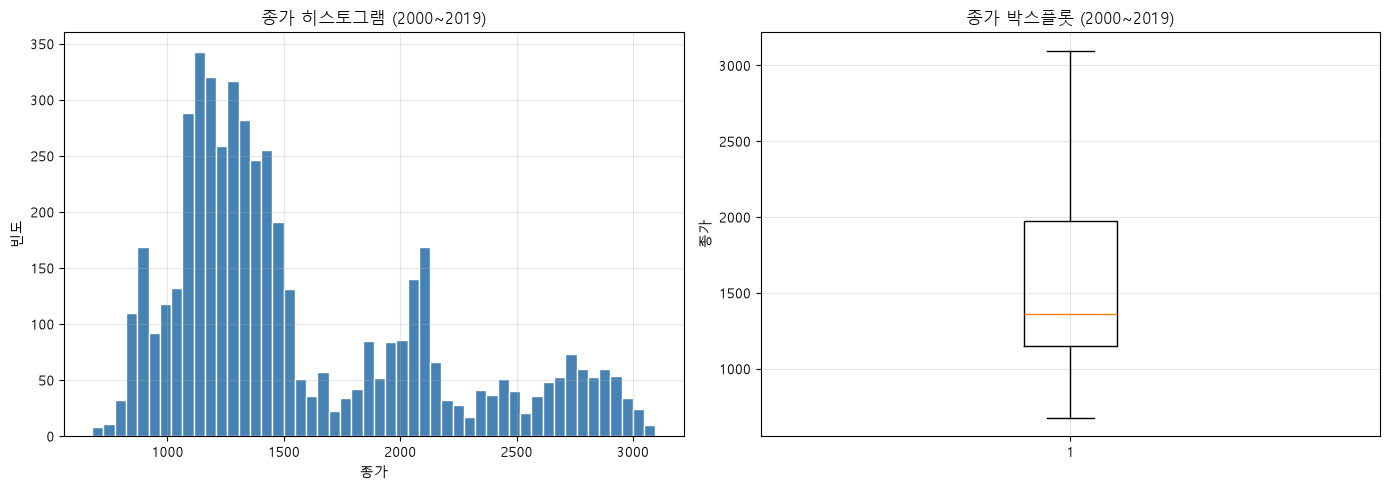

In [7]:
print("=== 종가 describe() ===")
print(df['종가'].describe())

print("\n=== 종가 주요 분위수 ===")
print(df['종가'].quantile([0.05, 0.25, 0.5, 0.75, 0.95]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['종가'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('종가 히스토그램 (2000~2019)')
axes[0].set_xlabel('종가')
axes[0].set_ylabel('빈도')

axes[1].boxplot(df['종가'], vert=True)
axes[1].set_title('종가 박스플롯 (2000~2019)')
axes[1].set_ylabel('종가')

plt.tight_layout()
plt.show()

## 8. 일간 수익률, 누적수익률, 변동성 분석

종가 기준 `pct_change()`로 일간 수익률을 계산하고, 누적수익률 곡선을 생성합니다. 롤링 표준편차로 변동성(20일, 60일)을 계산해 변동 구간을 확인합니다.

=== 일간 수익률 기초 통계 ===
count    4999.000000
mean        0.000222
std         0.011920
min        -0.090381
25%        -0.004738
50%         0.000540
75%         0.005675
max         0.115881
Name: 일간수익률, dtype: float64


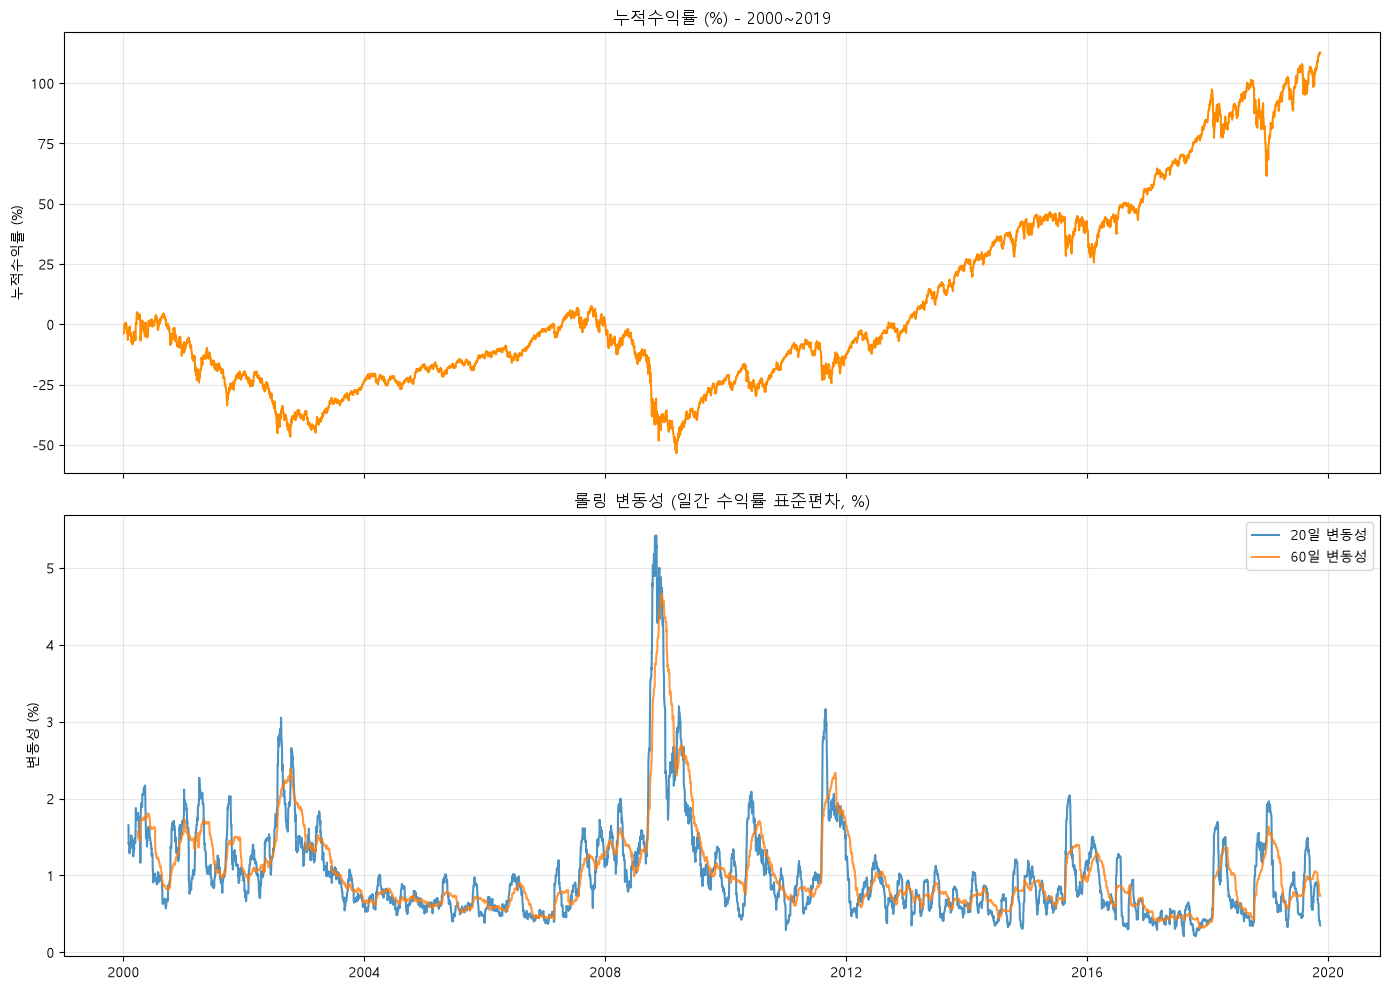

In [8]:
# 일간 수익률
df['일간수익률'] = df['종가'].pct_change()

# 누적수익률 (시작일 대비)
df['누적수익률'] = (1 + df['일간수익률']).cumprod() - 1

# 롤링 변동성 (20일, 60일 표준편차)
df['변동성_20일'] = df['일간수익률'].rolling(window=20).std()
df['변동성_60일'] = df['일간수익률'].rolling(window=60).std()

print("=== 일간 수익률 기초 통계 ===")
print(df['일간수익률'].describe())

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, df['누적수익률'] * 100, color='darkorange')
axes[0].set_title('누적수익률 (%) - 2000~2019')
axes[0].set_ylabel('누적수익률 (%)')

axes[1].plot(df.index, df['변동성_20일'] * 100, label='20일 변동성', alpha=0.8)
axes[1].plot(df.index, df['변동성_60일'] * 100, label='60일 변동성', alpha=0.8)
axes[1].set_title('롤링 변동성 (일간 수익률 표준편차, %)')
axes[1].set_ylabel('변동성 (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. 월/연 단위 리샘플링 및 성과 비교

`resample('ME')`, `resample('YE')`로 월말/연말 종가와 수익률을 집계해 기간별 성과를 비교합니다. 연도별 수익률을 표와 막대 그래프로 확인합니다.

=== 연도별 종가(연말 기준) 및 연간 수익률 ===


,연말종가,연간수익률(%)
날짜,,
2000,1320.3,NaN
2001,1148.1,-13.042490
2002,879.8,-23.369045
2003,1111.9,26.380996
2004,1211.9,8.993615
2005,1248.3,3.003548
2006,1418.3,13.618521
2007,1468.4,3.532398
2008,903.2,-38.490874


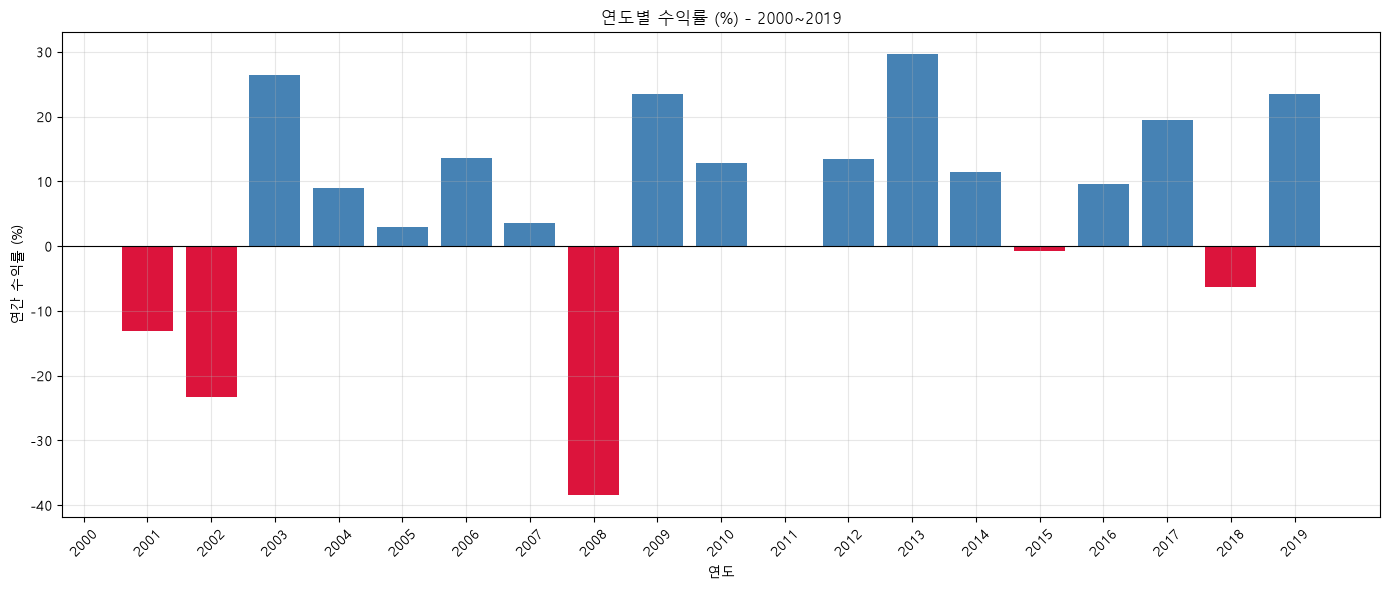

In [9]:
# 월말 종가 및 월간 수익률
monthly_close = df['종가'].resample('ME').last()
monthly_return = monthly_close.pct_change()

# 연말 종가 및 연간 수익률
yearly_close = df['종가'].resample('YE').last()
yearly_return = yearly_close.pct_change()
yearly_return.index = yearly_return.index.year

print("=== 연도별 종가(연말 기준) 및 연간 수익률 ===")
yearly_summary = pd.DataFrame({
    '연말종가': yearly_close.values,
    '연간수익률(%)': (yearly_return.values * 100)
}, index=yearly_close.index.year)
display(yearly_summary)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['crimson' if v < 0 else 'steelblue' for v in yearly_summary['연간수익률(%)']]
ax.bar(yearly_summary.index.astype(str), yearly_summary['연간수익률(%)'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('연도별 수익률 (%) - 2000~2019')
ax.set_xlabel('연도')
ax.set_ylabel('연간 수익률 (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. 최대 낙폭(Drawdown) 계산과 하락 구간 확인

누적 최고치 대비 하락률로 드로우다운을 계산하고, 최대 낙폭 값과 발생 시점을 추출합니다. 주요 하락 구간을 표로 정리합니다.

최대 낙폭(MDD): -56.78%
최대 낙폭 발생일: 2009-03-09
직전 고점일: 2007-10-09 (종가: 1565.20)

=== 드로우다운 -20% 이하 구간 샘플 ===


,종가,드로우다운(%)
날짜,,
2001-03-12,1180.2,-22.736498
2001-03-13,1197.7,-21.590835
2001-03-14,1166.7,-23.620295
2001-03-15,1173.6,-23.168576
2001-03-16,1150.5,-24.680851
2001-03-19,1170.8,-23.351882
2001-03-20,1142.6,-25.198036
2001-03-21,1122.1,-26.540098
2001-03-22,1117.6,-26.834697


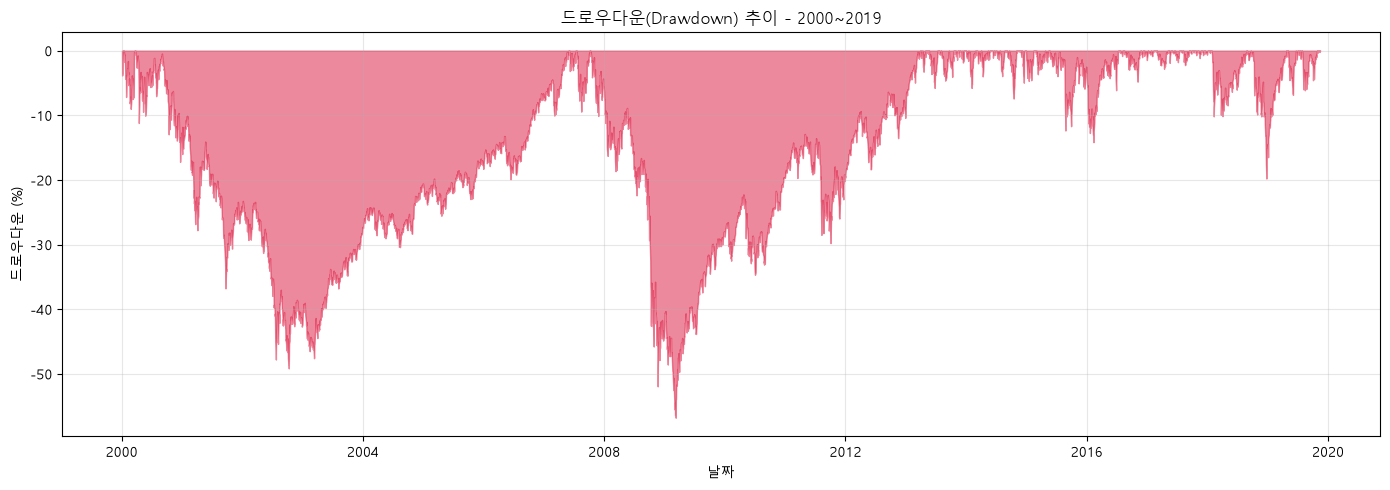

In [10]:
# 누적 최고치(running max) 대비 드로우다운 계산
running_max = df['종가'].cummax()
df['드로우다운'] = df['종가'] / running_max - 1

max_dd = df['드로우다운'].min()
max_dd_date = df['드로우다운'].idxmin()

# 최대 낙폭 시점 이전의 고점(전고점) 찾기
peak_date = df.loc[:max_dd_date, '종가'].idxmax()

print(f"최대 낙폭(MDD): {max_dd * 100:.2f}%")
print(f"최대 낙폭 발생일: {max_dd_date.date()}")
print(f"직전 고점일: {peak_date.date()} (종가: {df.loc[peak_date, '종가']:.2f})")

# 주요 하락 구간(드로우다운이 -20% 이하로 떨어진 구간) 요약
severe_dd = df[df['드로우다운'] <= -0.20][['종가', '드로우다운']].copy()
severe_dd['드로우다운(%)'] = severe_dd['드로우다운'] * 100
print("\n=== 드로우다운 -20% 이하 구간 샘플 ===")
display(severe_dd[['종가', '드로우다운(%)']].head(10))

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(df.index, df['드로우다운'] * 100, 0, color='crimson', alpha=0.5)
ax.set_title('드로우다운(Drawdown) 추이 - 2000~2019')
ax.set_xlabel('날짜')
ax.set_ylabel('드로우다운 (%)')
plt.tight_layout()
plt.show()

## 11. 종가 라인 그래프 시각화(전체 기간 및 구간 확대)

2000~2019 전체 종가 라인 그래프를 그리고 축/레이블/그리드/제목을 정리합니다. 2008년 금융위기 구간을 확대한 그래프도 함께 확인합니다.

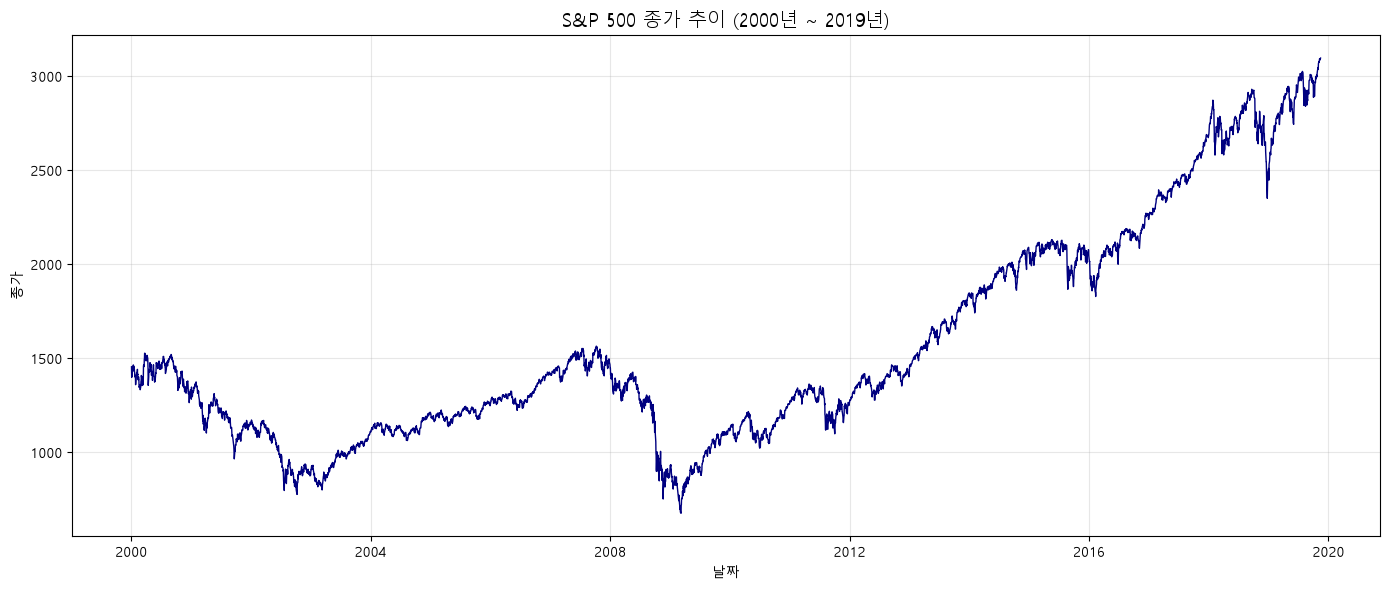

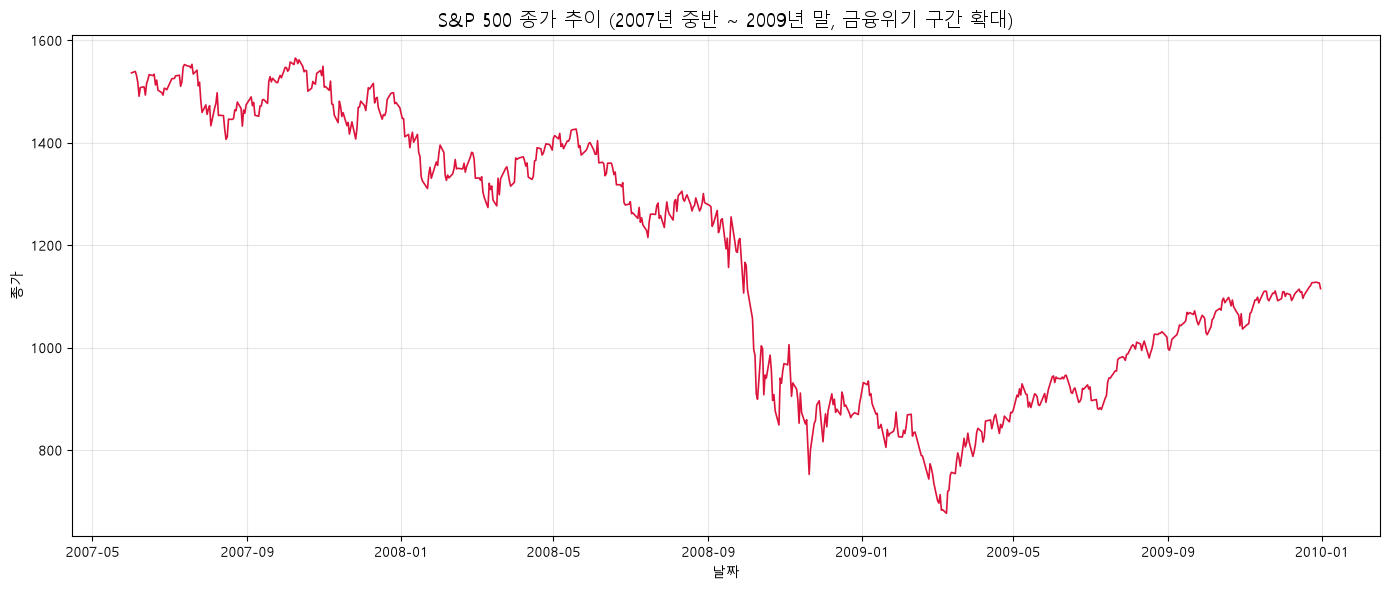

In [11]:
# 전체 기간(2000~2019) 종가 라인 그래프
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['종가'], color='navy', linewidth=1)
ax.set_title('S&P 500 종가 추이 (2000년 ~ 2019년)', fontsize=14)
ax.set_xlabel('날짜')
ax.set_ylabel('종가')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2008년 글로벌 금융위기 구간 확대 그래프
crisis_period = df.loc['2007-06-01':'2009-12-31']

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(crisis_period.index, crisis_period['종가'], color='crimson', linewidth=1.2)
ax.set_title('S&P 500 종가 추이 (2007년 중반 ~ 2009년 말, 금융위기 구간 확대)', fontsize=14)
ax.set_xlabel('날짜')
ax.set_ylabel('종가')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()